In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/brain-tumor-classification/dataset/archive.zip" -d "/content/drive/MyDrive/brain-tumor-classification/dataset/"

Archive:  /content/drive/MyDrive/brain-tumor-classification/dataset/archive.zip


In [15]:
!cp -r "/content/drive/MyDrive/brain-tumor-classification/dataset" /content/

In [ ]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

In [11]:
# Imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import classification_report, confusion_matrix

In [12]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

print("Mixed Precision:", mixed_precision.global_policy())

Mixed Precision: <DTypePolicy "mixed_float16">


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Classes:", class_names)

NameError: name 'train_dir' is not defined

In [ ]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Data Augmentation INSIDE model (runs on GPU)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze first 70%
total_layers = len(base_model.layers)
freeze_until = int(0.7 * total_layers)

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

for layer in base_model.layers[freeze_until:]:
    layer.trainable = True

# FULL MODEL PIPELINE
inputs = layers.Input(shape=(224, 224, 3))

# Apply augmentation only during training
x = data_augmentation(inputs)

# Preprocessing (VERY IMPORTANT for EfficientNet)
x = tf.keras.applications.efficientnet.preprocess_input(x)

# Base model
x = base_model(x, training=False)

# Head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = tf.keras.Model(inputs, outputs)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 3,086,816 (11.78 MB)

 Non-trainable params: 972,999 (3.71 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        "/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 126s 414ms/step - accuracy: 0.7382 - loss: 0.7360 - val_accuracy: 0.8505 - val_loss: 0.4337 - learning_rate: 1.0000e-04
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 117ms/step - accuracy: 0.8805 - loss: 0.3333 - val_accuracy: 0.9135 - val_loss: 0.2306 - learning_rate: 1.0000e-04
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9098 - loss: 0.2544 - val_accuracy: 0.9301 - val_loss: 0.1852 - learning_rate: 1.0000e-04
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 121ms/step - accuracy: 0.9306 - loss: 0.1883 - val_accuracy: 0.9414 - val_loss: 0.1592 - learning_rate: 1.0000e-04
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 124ms/step - accuracy: 0.9437 - loss: 0.1479 - val_accuracy: 0.9423 - val_loss: 0.1489 - learning_rate: 1.0000e-04
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step - accuracy: 0.9526 - loss: 0.1223 - val_accuracy: 0.9519 - val_loss: 0.1260 - learning_rate: 1.0000e-04
Epoch 7/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 18s 1

In [ ]:
def evaluate_model(model, dataset, class_names):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        preds = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    print("\n📊 Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

In [6]:
model = tf.keras.models.load_model(
    "/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras"
)

# evaluate_model(model, test_ds, class_names)

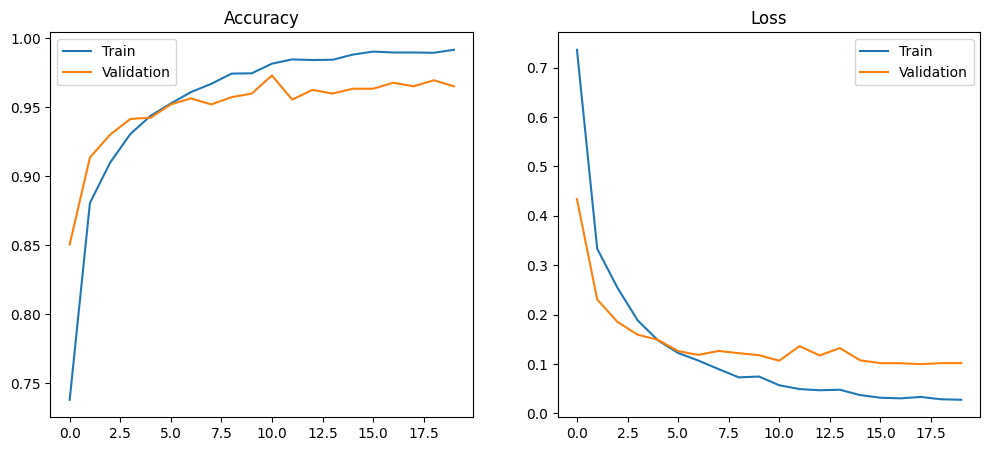

In [ ]:
def plot_history(history):
    plt.figure(figsize=(12, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Accuracy')
    plt.legend(['Train', 'Validation'])

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Loss')
    plt.legend(['Train', 'Validation'])

    plt.show()

plot_history(history)

In [ ]:
IMG_SIZE = (224, 224)

def predict_image(model, img_path, class_names):
    # Load image
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # Expand dims
    img_array = np.expand_dims(img_array, axis=0)

    # If your model has preprocessing inside → DO NOT preprocess again
    img_array = tf.cast(img_array, tf.float32)

    # Prediction
    preds = model.predict(img_array, verbose=0)
    pred_index = np.argmax(preds[0])
    confidence = float(np.max(preds[0]))

    return img, pred_index, confidence

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/brain-tumor-classification/models/best_model.keras')

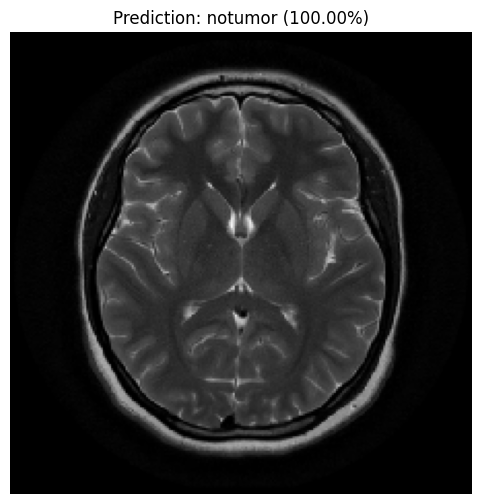

In [ ]:
# Random Testing
img, pred_index, confidence = predict_image(model, "/content/normal.png", class_names)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Prediction: {class_names[pred_index]} ({confidence:.2%})")
plt.axis("off")
plt.show()